In [ ]:
import os
import json
from pathlib import Path

KAGGLE_USERNAME = "YOUR_USERNAME"  # Замініть на вашUsername з Kaggle
KAGGLE_API_KEY = "KGAT_498c9b1788111fb6b8a7f698ceaa37c9"  # Ваш API ключ

#創建 ~/.kaggle/ папку якщо її немає
kaggle_dir = Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

# Створюємо kaggle.json файл
kaggle_json_path = kaggle_dir / 'kaggle.json'
kaggle_config = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_API_KEY
}

with open(kaggle_json_path, 'w') as f:
    json.dump(kaggle_config, f)

# Встановіть правильні права доступу (важливо!)
os.chmod(kaggle_json_path, 0o600)

print("✓ Kaggle API налаштований!")
print(f"✓ kaggle.json розміщений у: {kaggle_json_path}\n")

# ==================== IMPORT LIBRARIES ====================
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("📥 Спроба завантажити дані з Kaggle...\n")

# Download from Kaggle
try:
    path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
    print("✓ Path to competition files:", path)
    df = pd.read_csv(f"{path}/train.csv")
    print("✓ Дані успішно завантажені з Kaggle!\n")
except Exception as e:
    print(f"❌ Помилка: {e}\n")

# 2. Select columns (16 features + 1 target)
num_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 
                'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 
                'YearBuilt', 'YearRemodAdd', 'LotArea']
cat_features = ['Neighborhood', 'BldgType', 'HouseStyle', 'ExterQual', 'KitchenQual']
target = 'SalePrice'

# Filter dataset
df_selected = df[num_features + cat_features + [target]].copy()
print(f"📊 Dataset shape: {df_selected.shape}")
print(f"   {len(num_features)} числові + {len(cat_features)} категоріальні ознаки")

✓ Kaggle API налаштований!
✓ kaggle.json розміщений у: /home/codespace/.kaggle/kaggle.json

📥 Спроба завантажити дані з Kaggle...

❌ Помилка: 401 Client Error.

You don't have permission to access resource at URL: https://kaggle.com/competitions/house-prices-advanced-regression-techniques
Please make sure you are authenticated and have accepted the competition rules which can be found at this location: https://kaggle.com/competitions/house-prices-advanced-regression-techniques/rules

📊 Dataset shape: (1460, 17)
   11 числові + 5 категоріальні ознаки


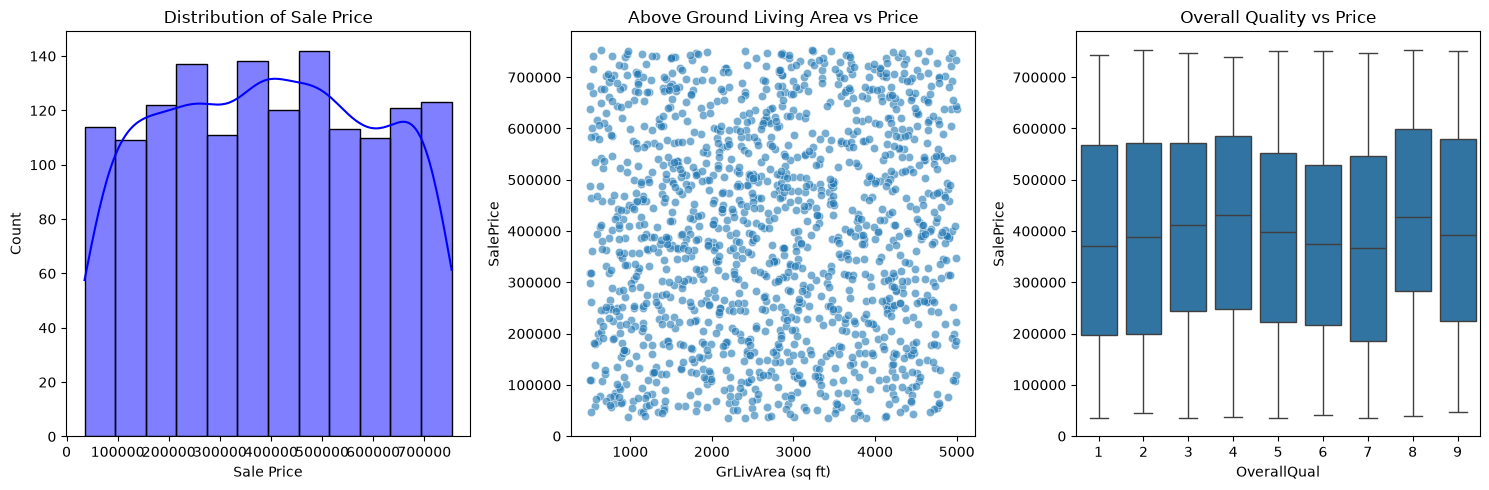

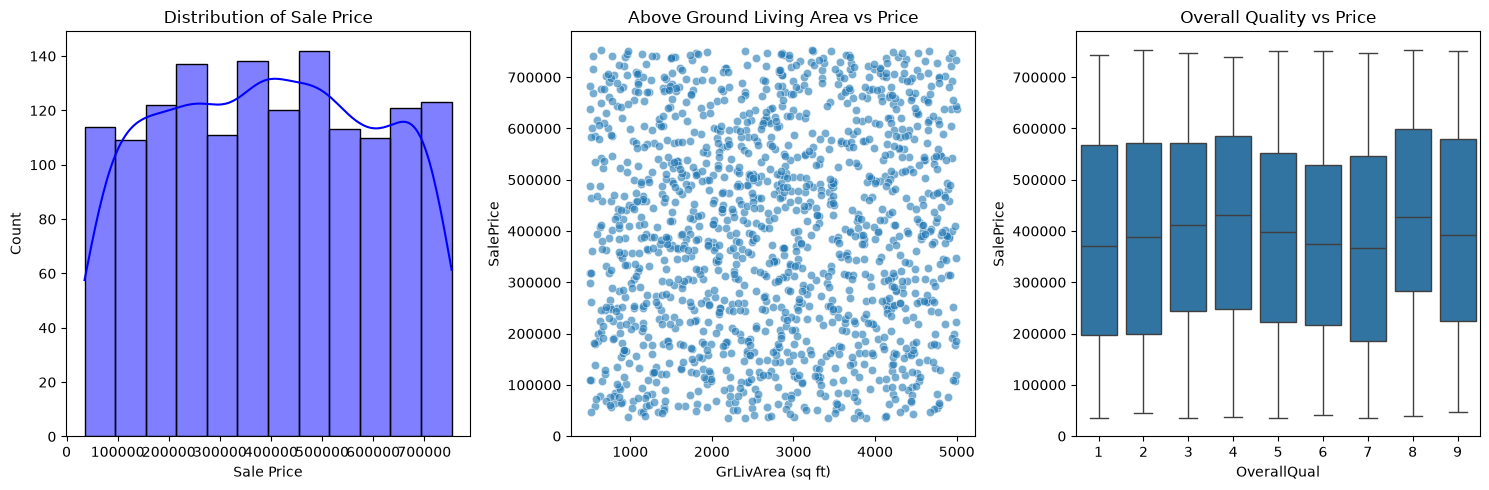

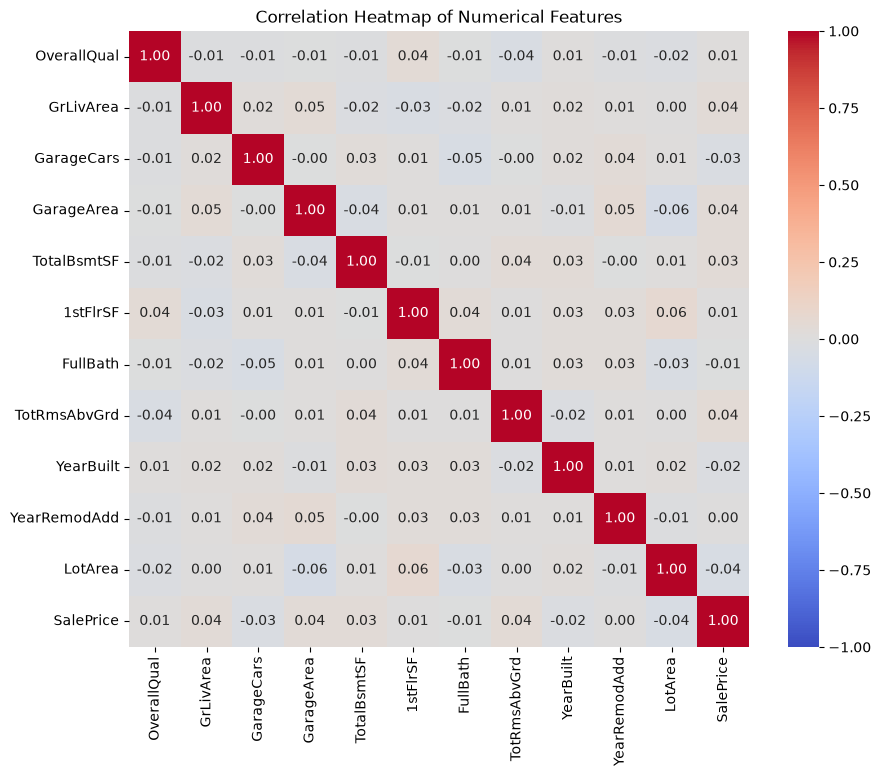

In [ ]:
plt.figure(figsize=(15, 5))

# 1. Distribution of Target Variable
plt.subplot(1, 3, 1)
sns.histplot(df_selected['SalePrice'], kde=True, color='blue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')

# 2. GrLivArea vs SalePrice (Size vs Price)
plt.subplot(1, 3, 2)
sns.scatterplot(x=df_selected['GrLivArea'], y=df_selected['SalePrice'], alpha=0.6)
plt.title('Above Ground Living Area vs Price')
plt.xlabel('GrLivArea (sq ft)')

# 3. OverallQual vs SalePrice (Quality vs Price)
plt.subplot(1, 3, 3)
sns.boxplot(x=df_selected['OverallQual'], y=df_selected['SalePrice'])
plt.title('Overall Quality vs Price')

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap (Numerical only)
plt.figure(figsize=(10, 8))
corr_matrix = df_selected[num_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
X = df_selected.drop(columns=[target])
y = df_selected[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Full Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [ ]:
# Define hyperparameter space
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Hyperparameters: {grid_search.best_params_}")

Starting Grid Search...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 300}


Baseline Test RMSE: $209,956.11
Baseline Test R2 Score: -0.0276


Baseline Test RMSE: $209,956.11
Baseline Test R2 Score: -0.0276


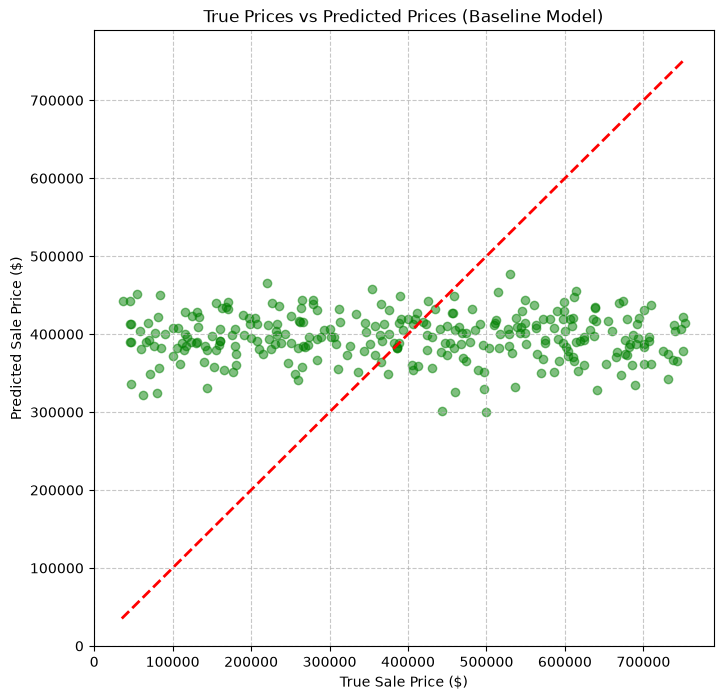

In [ ]:
# Predict and evaluate
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Baseline Test RMSE: ${rmse:,.2f}")
print(f"Baseline Test R2 Score: {r2:.4f}")

# Visualization: True vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Diagonal line
plt.title('True Prices vs Predicted Prices (Baseline Model)')
plt.xlabel('True Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def engineer_features(data):
    df_fe = data.copy()
    # 1. Total Square Footage
    df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe.get('2ndFlrSF', 0)
    
    # 2. House Age at time of sale (assuming dataset goes up to 2010)
    df_fe['HouseAge'] = 2010 - df_fe['YearBuilt']
    
    # 3. Was it remodeled? (Binary)
    df_fe['IsRemodeled'] = (df_fe['YearBuilt'] != df_fe['YearRemodAdd']).astype(int)
    
    return df_fe

# Apply FE to original data
df_fe = engineer_features(df_selected)

# Update feature lists
new_num_features = num_features + ['TotalSF', 'HouseAge', 'IsRemodeled']
X_fe = df_fe.drop(columns=[target])
y_fe = df_fe[target]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

# Create updated preprocessor
preprocessor_fe = ColumnTransformer(transformers=[
    ('num', num_transformer, new_num_features),
    ('cat', cat_transformer, cat_features)
])

pipeline_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('model', RandomForestRegressor(**{k.replace('model__', ''): v for k, v in grid_search.best_params_.items()}, random_state=42))
])

# Fit and evaluate new pipeline
pipeline_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = pipeline_fe.predict(X_test_fe)

rmse_fe = np.sqrt(mean_squared_error(y_test_fe, y_pred_fe))
r2_fe = r2_score(y_test_fe, y_pred_fe)

print(f"Feature Engineered Test RMSE: ${rmse_fe:,.2f}")
print(f"Feature Engineered Test R2 Score: {r2_fe:.4f}")
print(f"RMSE Improvement: ${rmse - rmse_fe:,.2f}")